# Settings

In [1]:
library(dplyr)
library(stringr)
library(tidyr)
library(Seurat)
library(Signac)
library(DESeq2)
library(ggplot2)
library(ggrepel)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘DESeq2’ was built under R version 4.3.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package 

# PCA

In [2]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/DESeq.meta.data.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,condition,Fibrosis.stage,Steatosis.grade,batch,Age,BMI,Gender,Age.scaled,BMI.scaled
,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,HL150001,392,1,541,5047,2779,MASL,0,1,thirdPR,47,27.1,M,-0.01553551,-0.6385847
2,HL150009,25,0,124,1655,513,MASL,0,1,fourthPR,37,29.4,M,-0.75778750,-0.3346869


[1] "donor_demux"           "Hepatocytes.Senescent" "Hepatocytes.Stress"   
 [4] "Hepatocytes.Zone1"     "Hepatocytes.Zone2"     "Hepatocytes.Zone3"    
 [7] "condition"             "Fibrosis.stage"        "Steatosis.grade"      
[10] "batch"                 "Age"                   "BMI"                  
[13] "Gender"                "Age.scaled"            "BMI.scaled"

In [3]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/02_DESEQ_ATAC/Hep.Subtype.Hep.Peaks/'
dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_Celltype_Union_Peaks_counts_spec_subset.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_Celltype_Union_Peaks_counts_spec_subset.tsv','', files)

files
cells

Warning message in dir.create(outdir):
“'/nfs/lab/projects/nash_nafld_liver/downstream_all/02_DESEQ_ATAC/Hep.Subtype.Hep.Peaks' already exists”


[1] "Hepatocytes.Senescent_Celltype_Union_Peaks_counts_spec_subset.tsv"
[2] "Hepatocytes.Stress_Celltype_Union_Peaks_counts_spec_subset.tsv"   
[3] "Hepatocytes.Zone1_Celltype_Union_Peaks_counts_spec_subset.tsv"    
[4] "Hepatocytes.Zone2_Celltype_Union_Peaks_counts_spec_subset.tsv"    
[5] "Hepatocytes.Zone3_Celltype_Union_Peaks_counts_spec_subset.tsv"

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [4]:
# List your contrasts  
conditions.1 = c("MASL", "MASH", "MetALD") # disease
conditions.2 = c("Control", "Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [5]:
unique(meta$condition)

[1] "MASL"    "MASH"    "MetALD"  "Control"

In [6]:
seq_along(files)

[1] 1 2 3 4 5

In [7]:
deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.1) %>% 
                               pull(donor)
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2
            tryCatch({
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
                
            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
                #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 329435     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 90 unlabeled data points (too many overlaps). Consider increasing m

[1] "Analyzing: Hepatocytes.Stress"
[1] 329435     15


Donors detectected with celltype: 15

subsetting metadata accordingly - Check that value is equal to above: 15

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

Skipping contrast MASL_vs_Control: 

  The design matrix has the same number of samples and coefficients to fit,
  so estimation of dispersion is not possible. Treating samples
  as replicates was deprecated in v1.20 and no longer supported since v1.22.



  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
Skipping contrast MASH_vs_Control: the model matrix is not full rank, so the model cannot be fit as specified.
  One or more variables or interaction terms in the design formula are linear
  c

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329435     85


Donors detectected with celltype: 85

subsetting metadata accordingly - Check that value is equal to above: 85

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 43 unlabeled data points (too many overlaps). Consider increasing m

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329435     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 93 unlabeled data points (too many overlaps). Consider increasing m

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329435     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - MASH_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 77 unlabeled data points (too many overlaps). Consider increasing m

In [8]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,3905,4372,0,0
Hepatocytes.Senescent,MASH_vs_Control,17131,2105,1155,43
Hepatocytes.Senescent,MetALD_vs_Control,25866,3019,8979,270
Hepatocytes.Zone1,MASL_vs_Control,4520,5361,0,0
Hepatocytes.Zone1,MASH_vs_Control,11316,1762,267,14
Hepatocytes.Zone1,MetALD_vs_Control,7116,3339,258,19
Hepatocytes.Zone2,MASL_vs_Control,4834,11908,1,0
Hepatocytes.Zone2,MASH_vs_Control,11107,4589,262,49
Hepatocytes.Zone2,MetALD_vs_Control,9280,7354,492,46


In [9]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control
<chr>,<int>,<int>,<int>
Hepatocytes.Senescent,0,1198,9249
Hepatocytes.Zone1,0,281,277
Hepatocytes.Zone2,1,311,538
Hepatocytes.Zone3,0,2403,3359


In [10]:
deseq.stats2 <- deseq.stats

In [12]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

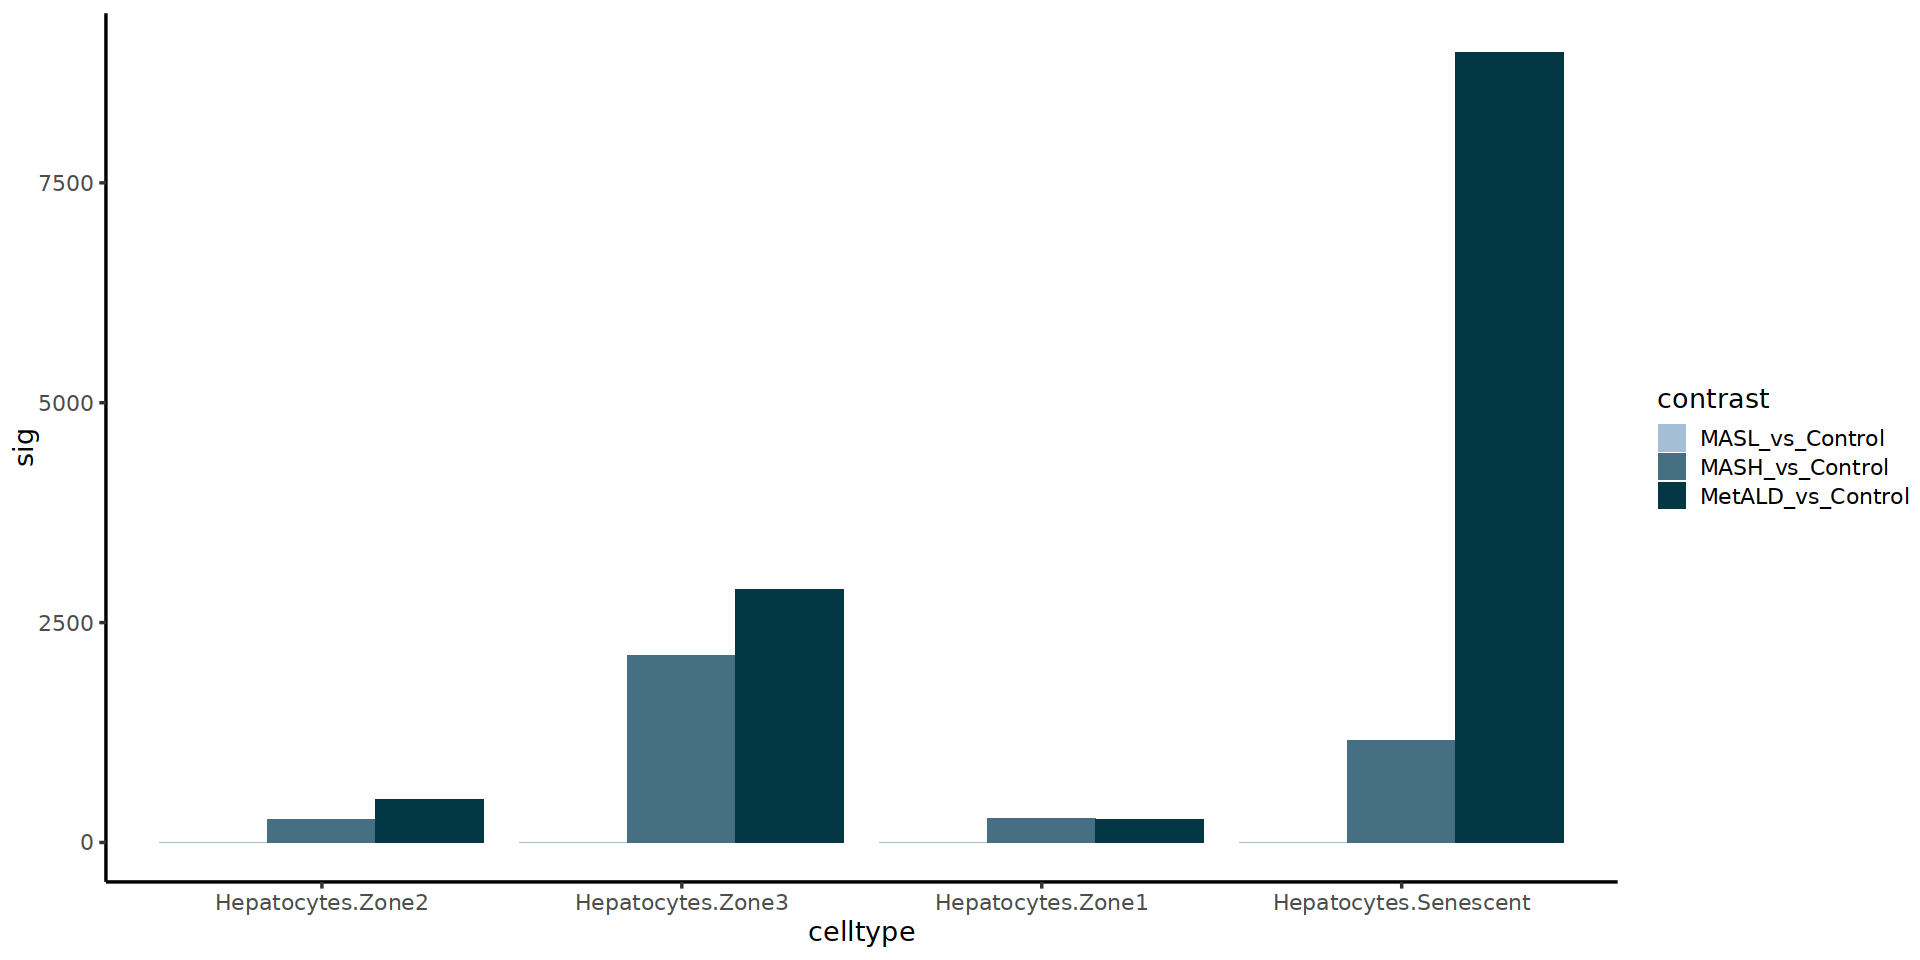

In [13]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### MASH_ALL

In [14]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    contrast.use <- 'MASH_ALL_vs_Control'
    
    condition.1 = c('MASH','MetALD')
    condition.2 = 'Control'
    message(" - ", contrast.use)

    # Create vectors of samples for each condition
    samples.condition.1 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.1) %>% 
                           pull(donor)
    samples.condition.2 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.2) %>% 
                           pull(donor)
    
    if(length(samples.condition.1) < 3) {
        next
    }
    if(length(samples.condition.2) < 3) {
        next
    }
    
    # Subset meta_cell for the current contrast
    meta_cell.use <- meta_cell %>% 
                 dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
    meta_cell.use[meta_cell.use$condition == 'MASH',]$condition <- 'MASH_ALL'
    meta_cell.use[meta_cell.use$condition == 'MetALD',]$condition <- 'MASH_ALL'
    rownames(meta_cell.use) <- meta_cell.use$donor
    
    # Subset raw_counts for the donors in meta_cell
    raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
    
    # Check if enough samples are present for both conditions
    if (length(unique(meta_cell$condition)) >= 2) {
        deseq.stats.tmp <- data.frame()
        
        # Light pre-filtering
        counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
        counts_filtered <- counts_filtered[,colSums(counts_filtered) > 0]

        # Run DESeq2
        tryCatch({
        dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                      colData = meta_cell.use, 
                                      design = deseq.formula)
        dds$condition <- relevel(dds$condition, ref = condition.2)
        dds <- DESeq(dds)
        dds.results <- results(dds)
            
        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
            
        dds.results <- na.omit(dds.results[order(dds.results$padj), ])

        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
        
        # Collect summary statistics
        deseq.stats.tmp <- data.frame(
            celltype = cell.use,
            contrast = contrast.use,
            up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
            down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
            up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
            down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
            deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                       # Make Volcano plot - Padj
                        res = as.data.frame(dds.results)
                        res$SYMBOL = rownames(res)
                        res = res %>%
                        dplyr::filter(!is.na(SYMBOL)) %>%
                        dplyr::filter(padj < 0.1) %>%
                        dplyr::group_by(sign(log2FoldChange)) %>%
                        dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                        dplyr::top_n(50, rank) %>%
                        dplyr::mutate(delabel = SYMBOL) %>%
                        ungroup() %>%
                        dplyr::select(delabel, SYMBOL) %>%
                        right_join(res) %>%
                        dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                        # Add a new column for color based on significance and direction
                        res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                            ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                        # Get the number of upregulated and downregulated genes
                        n_up <- sum(res$changes == "Up-regulated")
                        n_down <- sum(res$changes == "Down-regulated")

                        # Modify log2FoldChange values to be max x
                        res$log2FoldChange[res$log2FoldChange > 10] <- 10
                        res$log2FoldChange[res$log2FoldChange < -10] <- -10
                        # Modify padj values to be max x 
                        res$padj[res$padj < 10^-200] <- 10^-200
                
                        plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                            theme_bw() +
                            labs(y="-log10(padj)", x="log2FoldChange", 
                               title=paste(cell.use, " - ",
                                           condition.1, "Vs", condition.2, "\n",
                                          "Up: ", n_up, "-",
                                           "Down: ", n_down)) +
                            geom_point() +
                            scale_color_manual(values=c("blue", "grey", "red")) + 
                            theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                            scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                        labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                            scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                        labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                            geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                          point.padding=0, min.segment.length=0,
                                          max.time=20, max.iter=1e5, box.padding=0.3)
                
                        ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                               height = 10, width = 10,
                               plot = plot, device = "pdf")
            #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
    } else {
        message("Not enough samples for contrast: ", contrast.use)
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 329435     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 91 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Stress"
[1] 329435     15


Donors detectected with celltype: 15

subsetting metadata accordingly - Check that value is equal to above: 15

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

33 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 14 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone1"
[1] 329435     85


Donors detectected with celltype: 85

subsetting metadata accordingly - Check that value is equal to above: 85

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 86 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone2"
[1] 329435     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 94 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone3"
[1] 329435     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 92 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [20]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,3905,4372,0,0
Hepatocytes.Senescent,MASH_vs_Control,17131,2105,1155,43
Hepatocytes.Senescent,MetALD_vs_Control,25866,3019,8979,270
Hepatocytes.Zone1,MASL_vs_Control,4520,5361,0,0
Hepatocytes.Zone1,MASH_vs_Control,11316,1762,267,14
Hepatocytes.Zone1,MetALD_vs_Control,7116,3339,258,19
Hepatocytes.Zone2,MASL_vs_Control,4834,11908,1,0
Hepatocytes.Zone2,MASH_vs_Control,11107,4589,262,49
Hepatocytes.Zone2,MetALD_vs_Control,9280,7354,492,46


In [21]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control
<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,0,1198,9249,18075
Hepatocytes.Zone1,0,281,277,1843
Hepatocytes.Zone2,1,311,538,1879
Hepatocytes.Zone3,0,2403,3359,9400
Hepatocytes.Stress,NA,NA,NA,19


In [22]:
deseq.stats2 <- deseq.stats

In [23]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control"))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

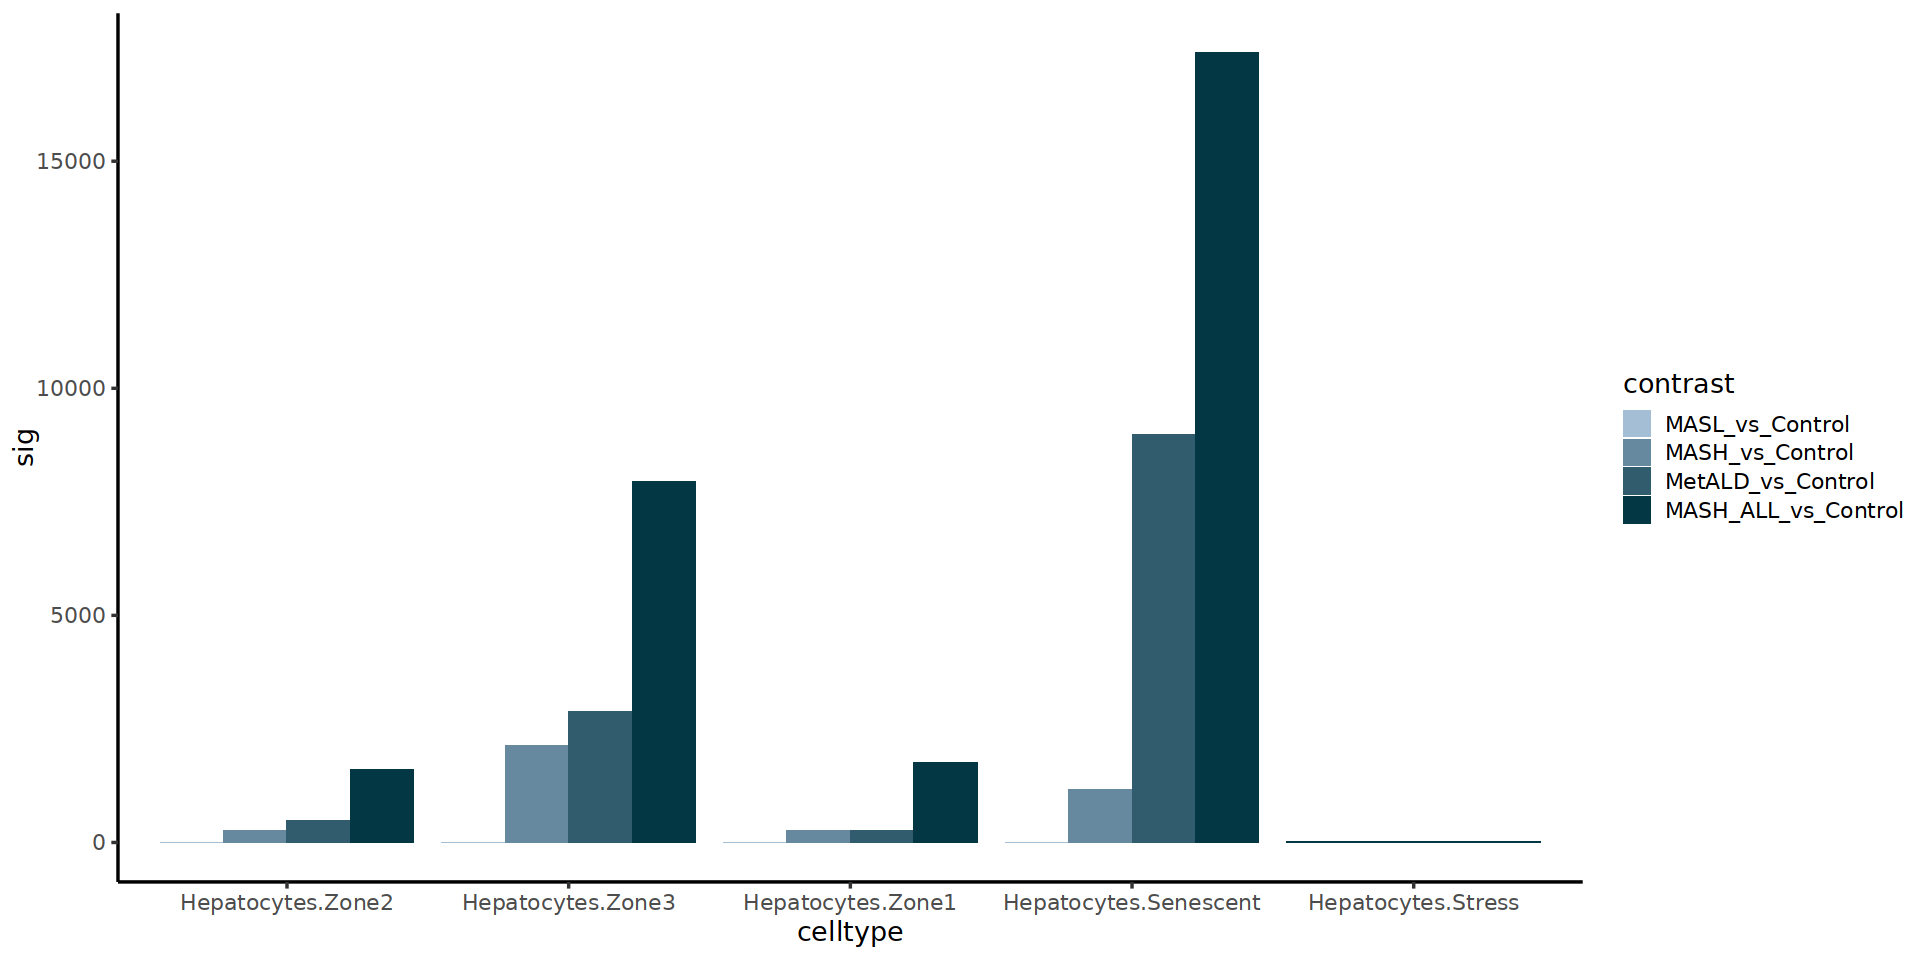

In [24]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### Fibrosis

In [25]:
contrasts  <- c('Fibrosis.stage')


# Define the DESeq2 formula
deseq.base.formula <- '~ Age.scaled + BMI.scaled + batch + Gender'

In [26]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 90 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Stress"
[1] 329435     15


Donors detectected with celltype: 15

Subsetting metadata accordingly - Check that value is equal to above: 15

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

17 rows did not conve

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329435     85


Donors detectected with celltype: 85

Subsetting metadata accordingly - Check that value is equal to above: 85

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 81 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone2"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 88 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes.Zone3"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 88 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [27]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,3905,4372,0,0
Hepatocytes.Senescent,MASH_vs_Control,17131,2105,1155,43
Hepatocytes.Senescent,MetALD_vs_Control,25866,3019,8979,270
Hepatocytes.Zone1,MASL_vs_Control,4520,5361,0,0
Hepatocytes.Zone1,MASH_vs_Control,11316,1762,267,14
Hepatocytes.Zone1,MetALD_vs_Control,7116,3339,258,19
Hepatocytes.Zone2,MASL_vs_Control,4834,11908,1,0
Hepatocytes.Zone2,MASH_vs_Control,11107,4589,262,49
Hepatocytes.Zone2,MetALD_vs_Control,9280,7354,492,46


In [28]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage
<chr>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,0,1198,9249,18075,53489
Hepatocytes.Zone1,0,281,277,1843,8962
Hepatocytes.Zone2,1,311,538,1879,19188
Hepatocytes.Zone3,0,2403,3359,9400,37763
Hepatocytes.Stress,NA,NA,NA,19,0


In [29]:
deseq.stats2 <- deseq.stats

In [30]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

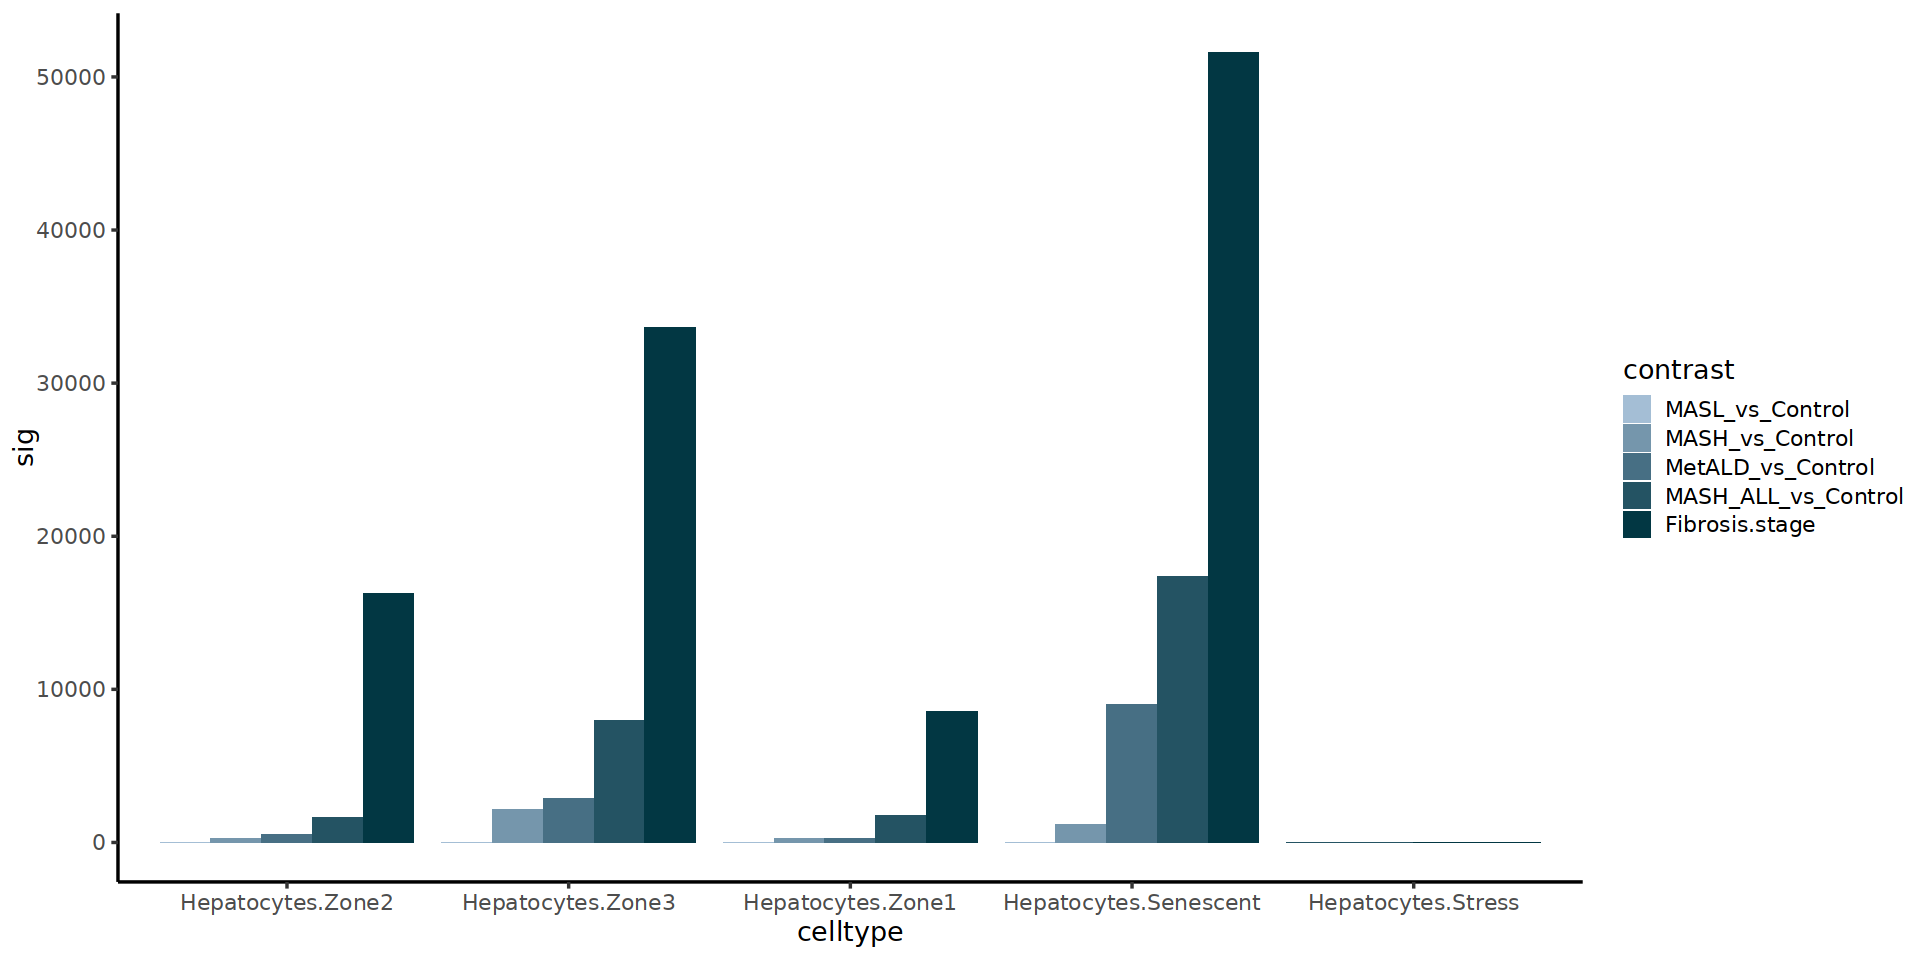

In [31]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [32]:
write.table(deseq.stats, paste0(outdir, '240920_WE_deseq_summary.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

### Other Meta

In [33]:
contrasts  <- c('Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + BMI.scaled + batch + Gender'

In [34]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - Lobular.inflammation

Not enough samples for contrast: Lobular.inflammation

  - Ballooning

Not enough samples for contrast: Ballooning

  - MASH.CRN.score..X.8

Not enough samples for contrast: MASH.CRN.score..X.8



[1] "Analyzing: Hepatocytes.Stress"
[1] 329435     15


Donors detectected with celltype: 15

Subsetting metadata accordingly - Check that value is equal to above: 15

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

210 rows did not con

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329435     85


Donors detectected with celltype: 85

Subsetting metadata accordingly - Check that value is equal to above: 85

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - Lobular.inflammation

Not enough samples for contrast: Lobular.inflammation

  - Ballooning

Not enough samples for contrast: Ballooning

  - MASH.CRN.score..X.8

Not enough samples for contrast: MASH.CRN.score..X.8



[1] "Analyzing: Hepatocytes.Zone2"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - Lobular.inflammation

Not enough samples for contrast: Lobular.inflammation

  - Ballooning

Not enough samples for contrast: Ballooning

  - MASH.CRN.score..X.8

Not enough samples for contrast: MASH.CRN.score..X.8



[1] "Analyzing: Hepatocytes.Zone3"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 13 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
  - Lobular.inflammation

Not enough samples for contrast: Lobular.inflammation

  - Ballooning

Not enough samples f

In [35]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,3905,4372,0,0
Hepatocytes.Senescent,MASH_vs_Control,17131,2105,1155,43
Hepatocytes.Senescent,MetALD_vs_Control,25866,3019,8979,270
Hepatocytes.Zone1,MASL_vs_Control,4520,5361,0,0
Hepatocytes.Zone1,MASH_vs_Control,11316,1762,267,14
Hepatocytes.Zone1,MetALD_vs_Control,7116,3339,258,19
Hepatocytes.Zone2,MASL_vs_Control,4834,11908,1,0
Hepatocytes.Zone2,MASH_vs_Control,11107,4589,262,49
Hepatocytes.Zone2,MetALD_vs_Control,9280,7354,492,46


In [36]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,0,1198,9249,18075,53489,2
Hepatocytes.Zone1,0,281,277,1843,8962,0
Hepatocytes.Zone2,1,311,538,1879,19188,4
Hepatocytes.Zone3,0,2403,3359,9400,37763,17
Hepatocytes.Stress,NA,NA,NA,19,0,0


In [37]:
deseq.stats2 <- deseq.stats

In [38]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

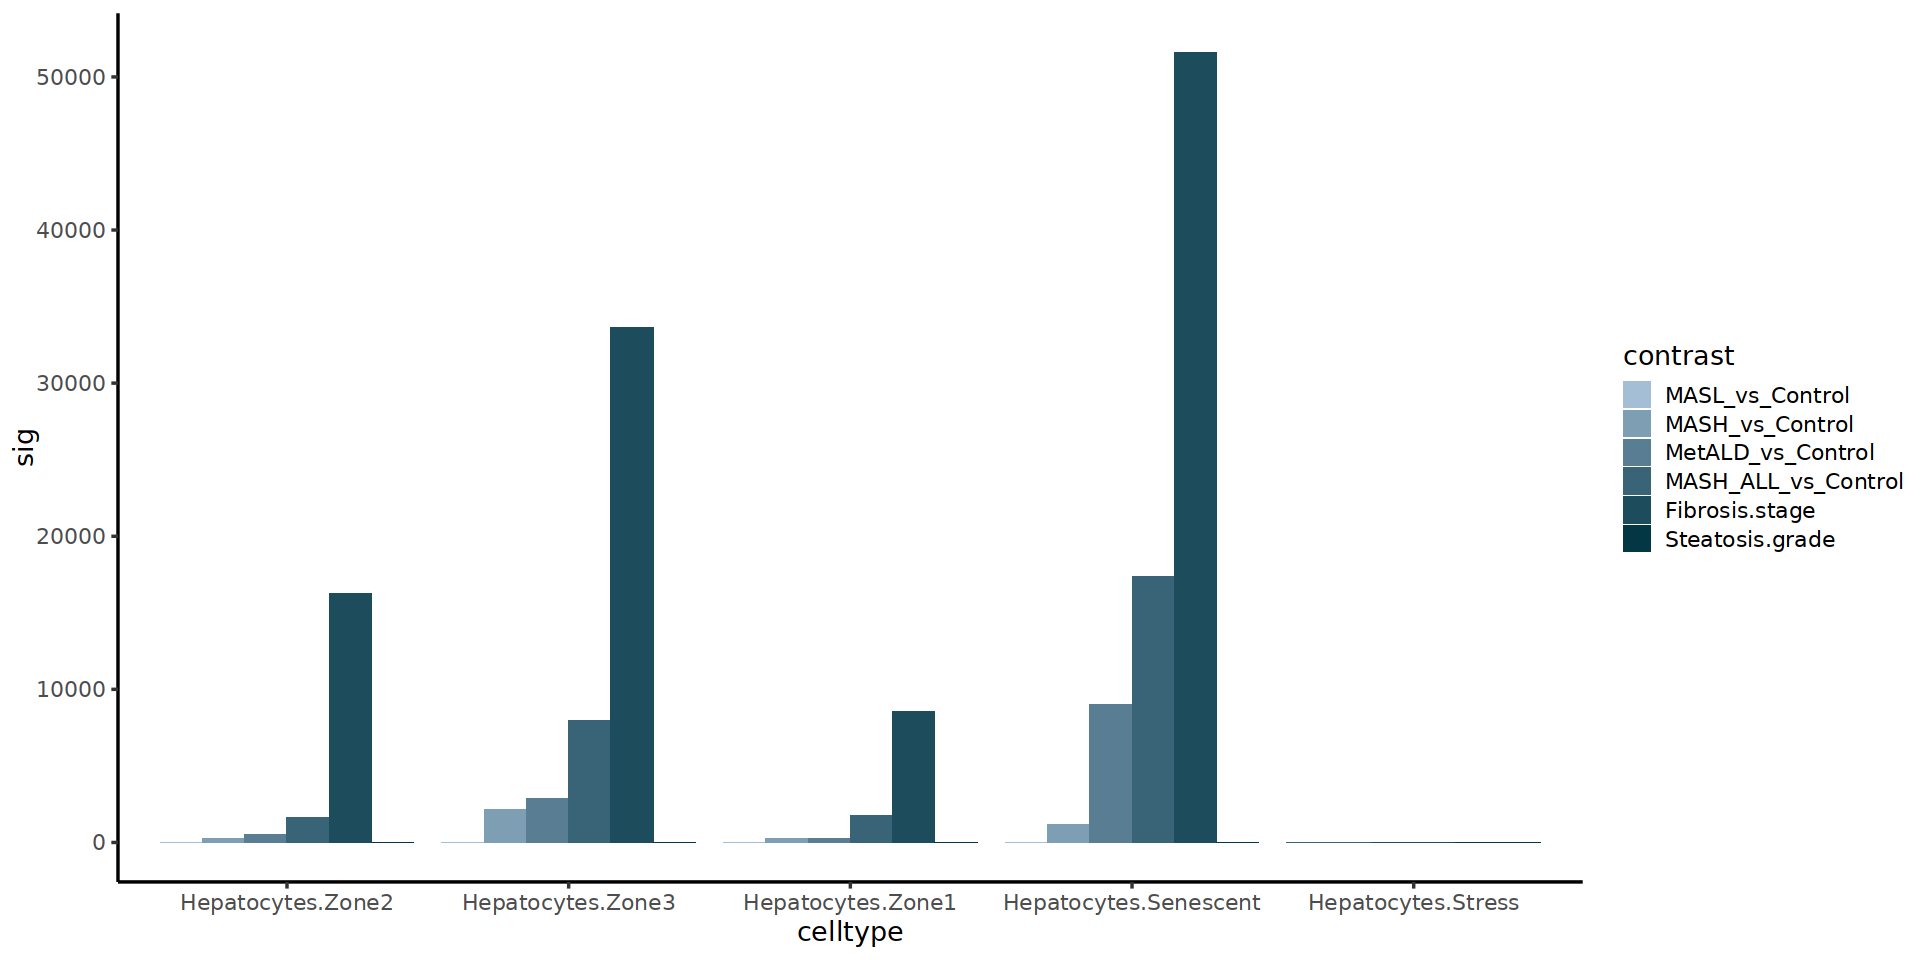

In [39]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(unique(deseq.stats2$contrast))))

In [40]:
length(unique(deseq.stats2$contrast))

[1] 6

In [41]:
contrasts  <- c('Age','Age.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + BMI.scaled + batch + Gender'

In [42]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Stress"
[1] 329435     15


Donors detectected with celltype: 15

Subsetting metadata accordingly - Check that value is equal to above: 15

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329435     85


Donors detectected with celltype: 85

Subsetting metadata accordingly - Check that value is equal to above: 85

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [43]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,3905,4372,0,0
Hepatocytes.Senescent,MASH_vs_Control,17131,2105,1155,43
Hepatocytes.Senescent,MetALD_vs_Control,25866,3019,8979,270
Hepatocytes.Zone1,MASL_vs_Control,4520,5361,0,0
Hepatocytes.Zone1,MASH_vs_Control,11316,1762,267,14
Hepatocytes.Zone1,MetALD_vs_Control,7116,3339,258,19
Hepatocytes.Zone2,MASL_vs_Control,4834,11908,1,0
Hepatocytes.Zone2,MASH_vs_Control,11107,4589,262,49
Hepatocytes.Zone2,MetALD_vs_Control,9280,7354,492,46


In [44]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Age,Age.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,0,1198,9249,18075,53489,2,0,0
Hepatocytes.Zone1,0,281,277,1843,8962,0,0,0
Hepatocytes.Zone2,1,311,538,1879,19188,4,51,51
Hepatocytes.Zone3,0,2403,3359,9400,37763,17,39,39
Hepatocytes.Stress,NA,NA,NA,19,0,0,0,1


In [45]:
deseq.stats2 <- deseq.stats

In [46]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

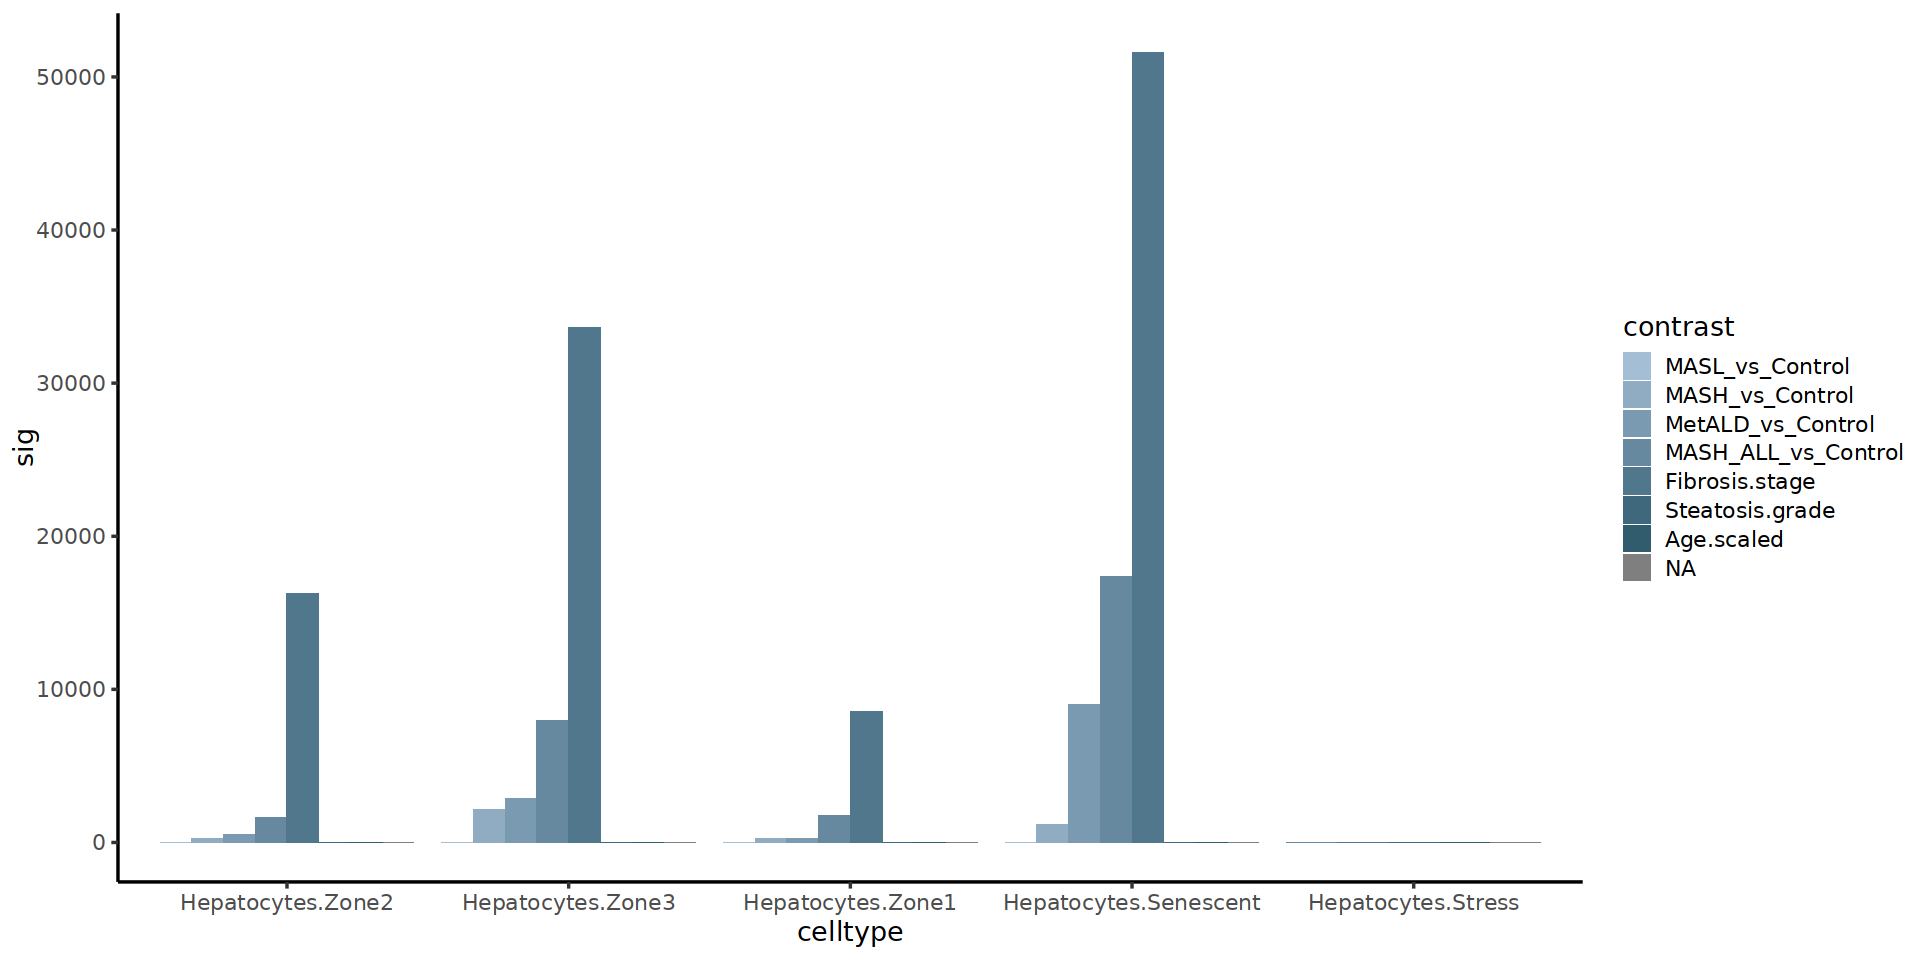

In [47]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [48]:
contrasts  <- c('BMI','BMI.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + batch + Gender'

In [49]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Stress"
[1] 329435     15


Donors detectected with celltype: 15

Subsetting metadata accordingly - Check that value is equal to above: 15

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329435     85


Donors detectected with celltype: 85

Subsetting metadata accordingly - Check that value is equal to above: 85

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329435     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [50]:
deseq.stats <- distinct(deseq.stats)
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,3905,4372,0,0
Hepatocytes.Senescent,MASH_vs_Control,17131,2105,1155,43
Hepatocytes.Senescent,MetALD_vs_Control,25866,3019,8979,270
Hepatocytes.Zone1,MASL_vs_Control,4520,5361,0,0
Hepatocytes.Zone1,MASH_vs_Control,11316,1762,267,14
Hepatocytes.Zone1,MetALD_vs_Control,7116,3339,258,19
Hepatocytes.Zone2,MASL_vs_Control,4834,11908,1,0
Hepatocytes.Zone2,MASH_vs_Control,11107,4589,262,49
Hepatocytes.Zone2,MetALD_vs_Control,9280,7354,492,46


In [51]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Age,Age.scaled,BMI,BMI.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,0,1198,9249,18075,53489,2,0,0,12,12
Hepatocytes.Zone1,0,281,277,1843,8962,0,0,0,6,6
Hepatocytes.Zone2,1,311,538,1879,19188,4,51,51,81,81
Hepatocytes.Zone3,0,2403,3359,9400,37763,17,39,39,46,46
Hepatocytes.Stress,NA,NA,NA,19,0,0,0,1,0,0


In [52]:
deseq.stats2 <- deseq.stats

In [53]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

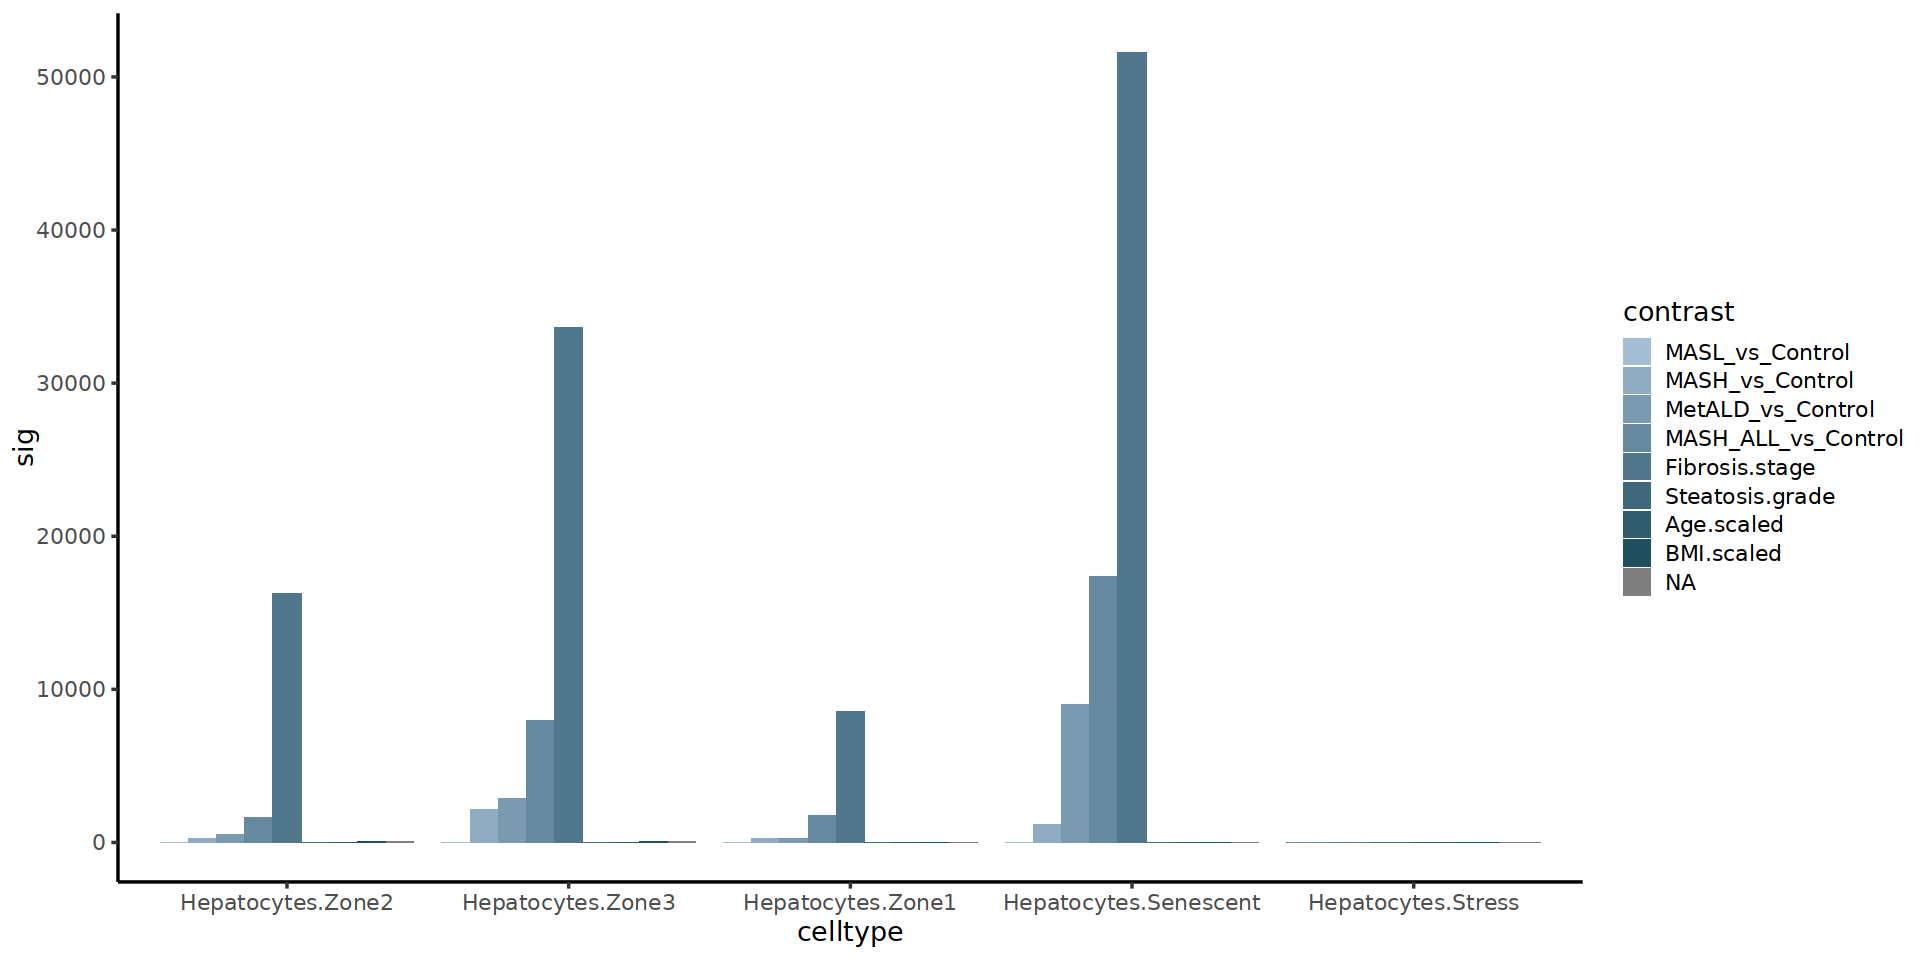

In [54]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [55]:
write.table(deseq.stats, paste0(outdir, '240920_WE_deseq_summary_add_contrasts_v2.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

In [68]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/DESeq.meta.data.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,condition,Fibrosis.stage,Steatosis.grade,batch,Age,BMI,Gender,Age.scaled,BMI.scaled
,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,HL150001,392,1,541,5047,2779,MASL,0,1,thirdPR,47,27.1,M,-0.01553551,-0.6385847
2,HL150009,25,0,124,1655,513,MASL,0,1,fourthPR,37,29.4,M,-0.75778750,-0.3346869


[1] "donor_demux"           "Hepatocytes.Senescent" "Hepatocytes.Stress"   
 [4] "Hepatocytes.Zone1"     "Hepatocytes.Zone2"     "Hepatocytes.Zone3"    
 [7] "condition"             "Fibrosis.stage"        "Steatosis.grade"      
[10] "batch"                 "Age"                   "BMI"                  
[13] "Gender"                "Age.scaled"            "BMI.scaled"

In [69]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/02_DESEQ_ATAC/Hep.Subtype.Hep.Peaks/'
dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_Celltype_Union_Peaks_counts_spec_subset.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_Celltype_Union_Peaks_counts_spec_subset.tsv','', files)

files
cells

Warning message in dir.create(outdir):
“'/nfs/lab/projects/nash_nafld_liver/downstream_all/02_DESEQ_ATAC/Hep.Subtype.Hep.Peaks' already exists”


[1] "Hepatocytes.Senescent_Celltype_Union_Peaks_counts_spec_subset.tsv"
[2] "Hepatocytes.Stress_Celltype_Union_Peaks_counts_spec_subset.tsv"   
[3] "Hepatocytes.Zone1_Celltype_Union_Peaks_counts_spec_subset.tsv"    
[4] "Hepatocytes.Zone2_Celltype_Union_Peaks_counts_spec_subset.tsv"    
[5] "Hepatocytes.Zone3_Celltype_Union_Peaks_counts_spec_subset.tsv"

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [70]:
deseq.stats2 <- read.table(paste0(outdir, '240920_WE_deseq_summary_add_contrasts_v2.tsv'),
           header=T, sep='\t')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

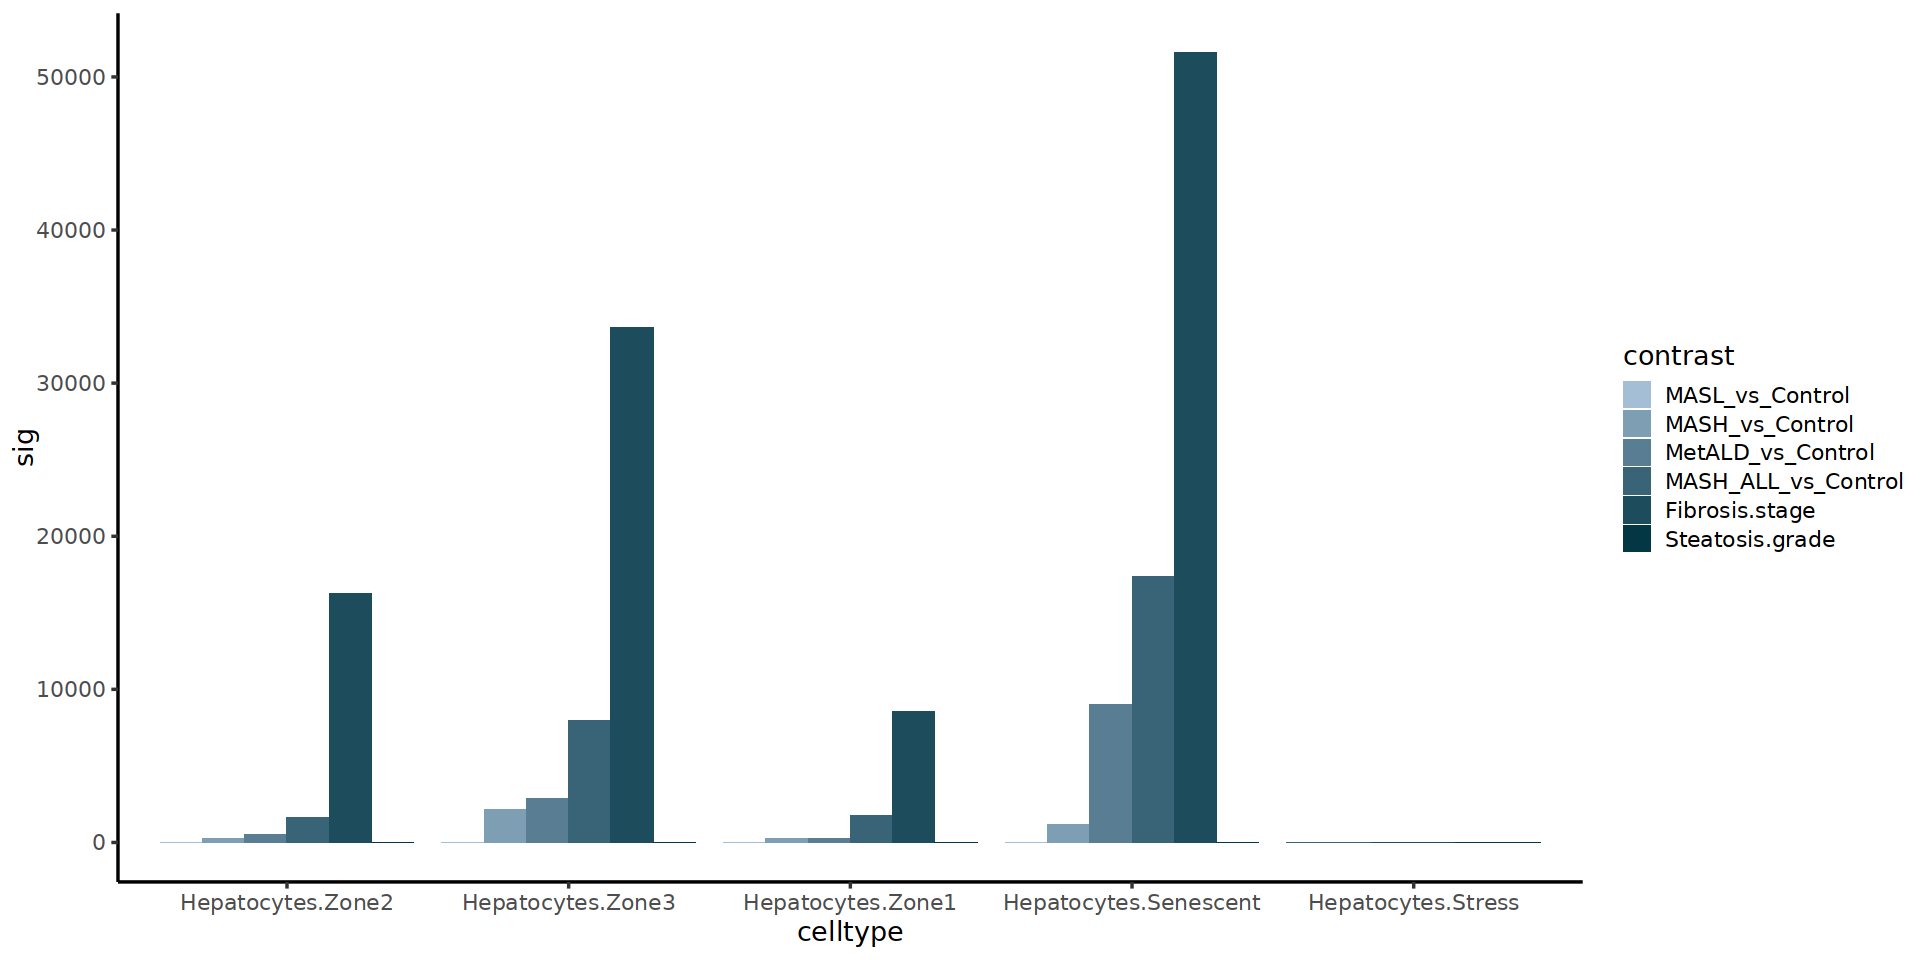

In [71]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
       filter(contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',
                             'Fibrosis.stage','Steatosis.grade','MASH_ALL_vs_Control')) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(6))

In [72]:
library(dplyr)
filter(deseq.stats2, contrast=='Fibrosis.stage')

,celltype,contrast,up_pval,down_pval,up_padj,down_padj
,<fct>,<fct>,<int>,<int>,<int>,<int>
18,Hepatocytes.Senescent,Fibrosis.stage,70799,3595,51579,1910
19,Hepatocytes.Stress,Fibrosis.stage,1923,403,0,0
20,Hepatocytes.Zone1,Fibrosis.stage,31071,3489,8551,411
21,Hepatocytes.Zone2,Fibrosis.stage,40430,10610,16260,2928
22,Hepatocytes.Zone3,Fibrosis.stage,57208,8750,33637,4126


In [73]:
# List your contrasts  
conditions.1 = c("Low_Fibrosis", "High_Fibrosis") # disease
conditions.2 = c("Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [74]:
unique(meta$condition)

[1] "MASL"    "MASH"    "MetALD"  "Control"

In [75]:
seq_along(files)

[1] 1 2 3 4 5

In [76]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        if (condition.1 == 'Low_Fibrosis') {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage <= 2) %>% 
                               pull(donor)
        } else {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage >= 3) %>% 
                               pull(donor)
        }
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2
            tryCatch({
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
                
            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
                #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 329435     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 85 unlabeled data points (too many overlaps). Cons

[1] "Analyzing: Hepatocytes.Stress"
[1] 329435     15


Donors detectected with celltype: 15

subsetting metadata accordingly - Check that value is equal to above: 15

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

Skipping contrast Low_Fibrosis_vs_Control: 

  The design matrix has the same number of samples and coefficients to fit,
  so estimation of dispersion is not possible. Treating samples
  as replicates was deprecated in v1.20 and no longer supported since v1.22.



  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
Skipping contrast High_Fibrosis_vs_Control: the model matrix is not full rank, so the model cannot be fit as specified.
  One or more variables or interaction terms in

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329435     85


Donors detectected with celltype: 85

subsetting metadata accordingly - Check that value is equal to above: 85

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 75 unlabeled data points (too many overlaps). Cons

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329435     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 82 unlabeled data points (too many overlaps). Cons

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329435     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 16 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
  - High_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joinin

In [77]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,3905,4372,0,0
Hepatocytes.Senescent,MASH_vs_Control,17131,2105,1155,43
Hepatocytes.Senescent,MetALD_vs_Control,25866,3019,8979,270
Hepatocytes.Zone1,MASL_vs_Control,4520,5361,0,0
Hepatocytes.Zone1,MASH_vs_Control,11316,1762,267,14
Hepatocytes.Zone1,MetALD_vs_Control,7116,3339,258,19
Hepatocytes.Zone2,MASL_vs_Control,4834,11908,1,0
Hepatocytes.Zone2,MASH_vs_Control,11107,4589,262,49
Hepatocytes.Zone2,MetALD_vs_Control,9280,7354,492,46


In [84]:
outdir

[1] "/nfs/lab/projects/nash_nafld_liver/downstream_all/02_DESEQ_ATAC/Hep.Subtype.Hep.Peaks/"

In [78]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Age,Age.scaled,BMI,BMI.scaled,Low_Fibrosis_vs_Control,High_Fibrosis_vs_Control
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,0,1198,9249,18075,53489,2,0,0,12,12,4,20013
Hepatocytes.Zone1,0,281,277,1843,8962,0,0,0,6,6,4,1292
Hepatocytes.Zone2,1,311,538,1879,19188,4,51,51,81,81,1,2408
Hepatocytes.Zone3,0,2403,3359,9400,37763,17,39,39,46,46,30,12052
Hepatocytes.Stress,NA,NA,NA,19,0,0,0,1,0,0,NA,NA


In [79]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Age,Age.scaled,BMI,BMI.scaled,Low_Fibrosis_vs_Control,High_Fibrosis_vs_Control
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,0,1198,9249,18075,53489,2,0,0,12,12,4,20013
Hepatocytes.Zone1,0,281,277,1843,8962,0,0,0,6,6,4,1292
Hepatocytes.Zone2,1,311,538,1879,19188,4,51,51,81,81,1,2408
Hepatocytes.Zone3,0,2403,3359,9400,37763,17,39,39,46,46,30,12052
Hepatocytes.Stress,NA,NA,NA,19,0,0,0,1,0,0,NA,NA


In [85]:
deseq.stats2 <- deseq.stats

In [89]:
deseq.stats2 <- filter(deseq.stats2, contrast != 'BMI' & contrast != 'Age')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'Age.scaled', 'BMI.scaled','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:6]), decreasing = T))))                           

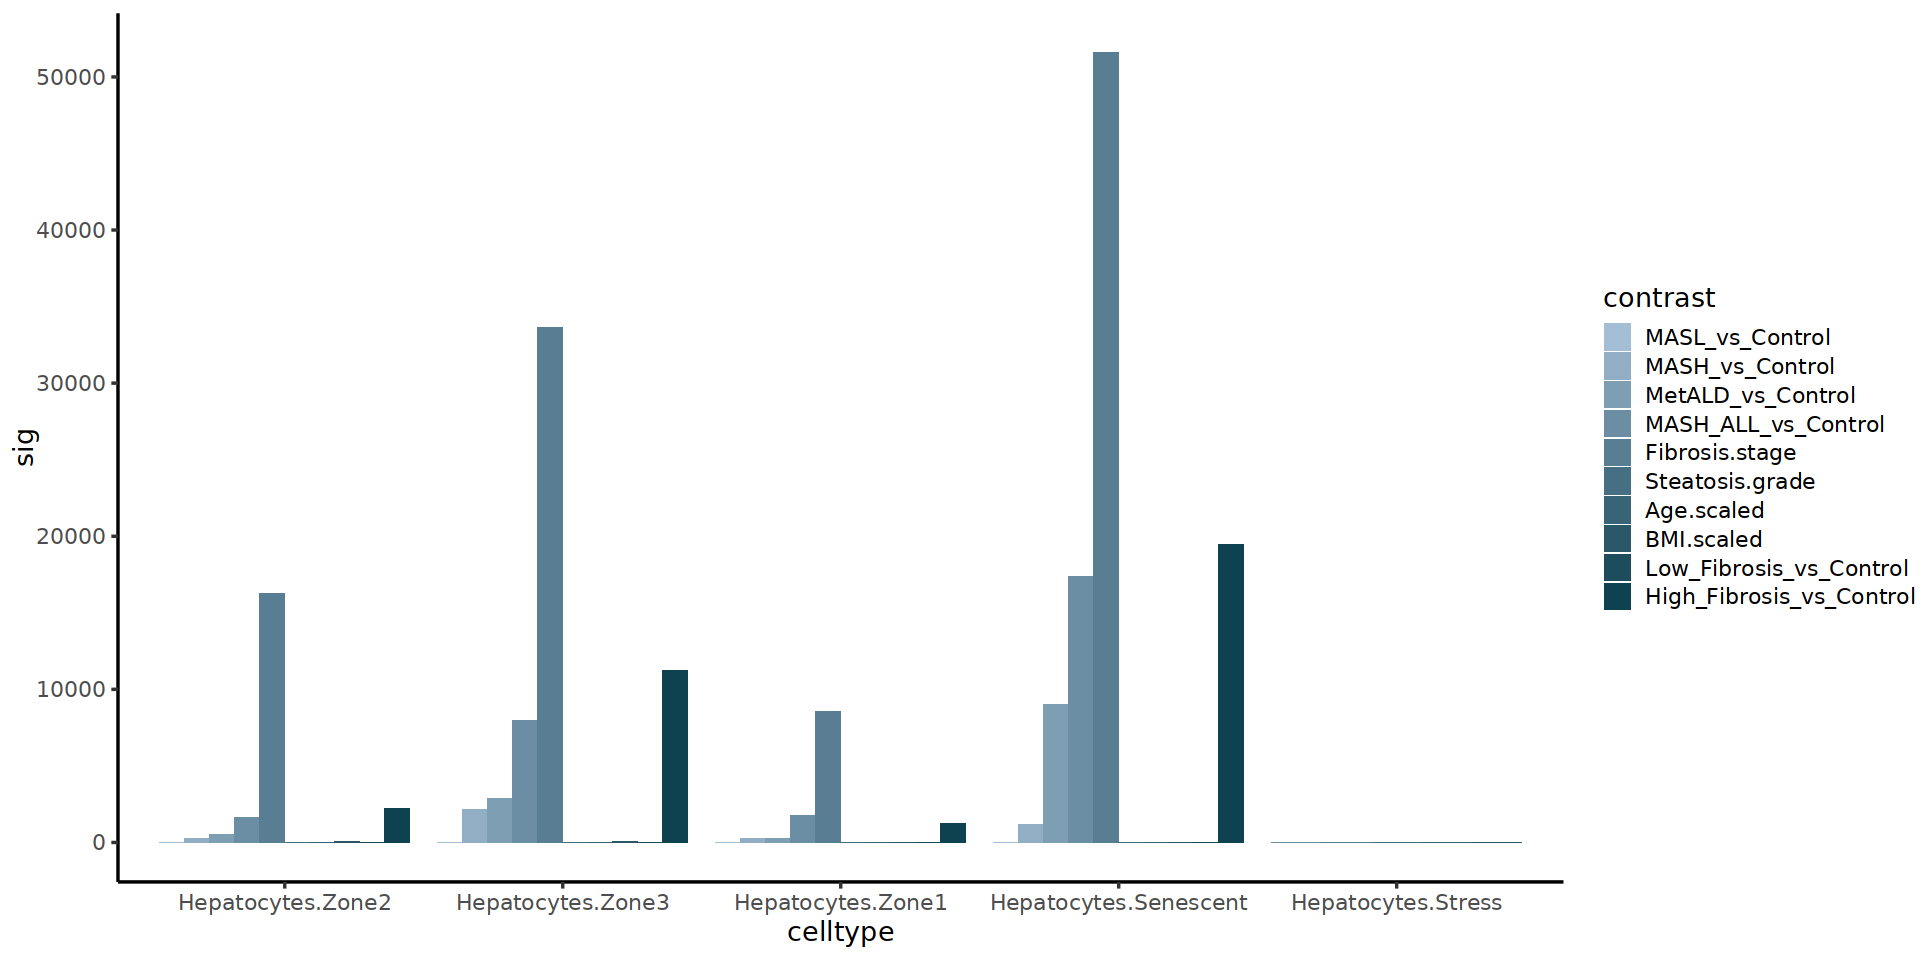

In [91]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))